# Day1A: Neural Trajectory Divergence Analysis

This notebook implements the Day1A analysis plan for detecting when STOP trial neural trajectories diverge from GO baseline.

**Approach:**
- Fit Poisson mean trajectory from GO trials (per session, per direction)
- Score STOP SSD2 trials using cumulative surprise (negative log-likelihood)
- Detect divergence time using calibrated family-wise threshold

**Session:** fi211115a (to start)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)

from session_class import Session
from cell_analysis import Cell

print("Imports loaded successfully!")

Imports loaded successfully!


## 1. Load Data

In [16]:
# Load MSN cell database
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'
cell_df = pd.read_pickle(pickle_file)

# Select session fi211115a
session_id = 'fi211025a'
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)


# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nSession {session_id} loaded successfully!")
print(f"Number of cells after filtering: {session.n_cells}")
print(f"Total cell-trial combinations: {len(session.data)}")

Session fi211025a initialized:
  - Number of cells: 63
  - Total trials: 685
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

Session fi211025a loaded successfully!
Number of cells after filtering: 63
Total cell-trial combinations: 33136


In [17]:
# Load synthetic session data
session_id = 'synthetic_session'
synthetic_pickle_file = base_path / 'synthetic_session_data.pkl'
synthetic_df =pd.read_pickle(synthetic_pickle_file)
session = Session(synthetic_df, verbose=True)

Session synthetic_session initialized:
  - Number of cells: 2
  - Total trials: 12
  - Trial types: ['GO', 'STOP']
  - Directions: [np.int64(180)]


## 2. Check Trial Counts

Verify we have enough GO and STOP SSD2 trials for each direction.

In [18]:
# Count successful trials for GO and STOP SSD2 by direction
ssd_num = 2
dir_map = {0: 'Right', 180: 'Left'}

results = []
for direction in [0, 180]:
    dir_name = dir_map[direction]
    
    # GO trials (successful only) - count unique trial numbers
    go_count = len(session.data[
        (session.data['type'] == 'GO') & 
        (session.data['dir'] == direction) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'GO', 'Trial Count': go_count})
    
    # STOP SSD2 trials (successful only)
    stop_count = len(session.data[
        (session.data['type'] == 'STOP') & 
        (session.data['dir'] == direction) & 
        (session.data['ssd_number'] == ssd_num) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'STOP SSD2', 'Trial Count': stop_count})

results_df = pd.DataFrame(results)
print("\nSuccessful Trial Counts:")
print("=" * 40)
print(results_df.to_string(index=False))


Successful Trial Counts:
Direction      Type  Trial Count
    Right        GO            0
    Right STOP SSD2            0
     Left        GO           10
     Left STOP SSD2            2


In [19]:
session.data['first_relevant_saccade']

0       [4300.0, 4350.0]
1       [4300.0, 4350.0]
2       [7300.0, 7350.0]
3       [7300.0, 7350.0]
4     [10300.0, 10350.0]
5     [10300.0, 10350.0]
6     [13300.0, 13350.0]
7     [13300.0, 13350.0]
8     [16300.0, 16350.0]
9     [16300.0, 16350.0]
10    [19300.0, 19350.0]
11    [19300.0, 19350.0]
12    [22300.0, 22350.0]
13    [22300.0, 22350.0]
14    [25300.0, 25350.0]
15    [25300.0, 25350.0]
16    [28300.0, 28350.0]
17    [28300.0, 28350.0]
18    [31300.0, 31350.0]
19    [31300.0, 31350.0]
20            [nan, nan]
21            [nan, nan]
22            [nan, nan]
23            [nan, nan]
Name: first_relevant_saccade, dtype: object

## 3. Spike Binning Function

Bin spikes into 10ms bins over [-50, 300]ms window relative to go_cue.

In [20]:
def bin_spikes_for_trials(session_data, trial_type, direction, ssd_number=None, 
                          success_only=True, epok=[-50, 300], bin_size=10,
                          alignment_point='go_cue', bin_step=None):
    """
    Bin spikes for a set of trials into a matrix.
    
    Parameters:
    -----------
    session_data : pd.DataFrame
        Session data (all cells, all trials)
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : int, optional
        SSD number (1-4), only for STOP/CONT trials
    success_only : bool
        Include only successful trials
    epok : list
        Time window [start, end] in ms
    bin_size : int
        Bin width in ms
    alignment_point : str
        Event to align to
    bin_step : int, optional
        Step size for sliding window bins in ms. If None, uses non-overlapping bins (step=bin_size).
        For overlapping bins, use bin_step < bin_size (e.g., bin_step=1 for 1ms steps)
    
    Returns:
    --------
    dict : {'counts': (n_trials, n_neurons, n_bins), 'bin_centers': array, 
            'cell_ids': list, 'trial_numbers': list}
    """
    # Filter trials
    mask = (session_data['type'] == trial_type) & (session_data['dir'] == direction)
    if success_only:
        mask &= (session_data['trial_failed'] == False)
    if ssd_number is not None and trial_type in ['STOP', 'CONT']:
        mask &= (session_data['ssd_number'] == ssd_number)
    
    filtered_data = session_data[mask].copy()
    
    if len(filtered_data) == 0:
        return None
    
    # Get unique trials and cells
    trial_numbers = sorted(filtered_data['trial_number'].unique())
    cell_ids = sorted(filtered_data['cell_ID'].unique())
    
    n_trials = len(trial_numbers)
    n_neurons = len(cell_ids)
    
    # Determine bin step
    if bin_step is None:
        bin_step = bin_size  # Non-overlapping bins
    
    # Create sliding window bins
    # Bin timestamps are the right edges (last time of each bin)
    # First bin: (epok[0], epok[0] + bin_size), timestamp = epok[0] + bin_size
    # Last bin: (epok[1] - bin_size, epok[1]), timestamp = epok[1]
    bin_edges_right = np.arange(epok[0] + bin_size, epok[1] + 1, bin_step)
    n_bins = len(bin_edges_right)
    
    # Initialize count matrix: (n_trials, n_neurons, n_bins)
    counts = np.zeros((n_trials, n_neurons, n_bins), dtype=int)
    
    # Bin spikes for each trial and neuron
    for trial_idx, trial_num in enumerate(trial_numbers):
        trial_data = filtered_data[filtered_data['trial_number'] == trial_num]
        
        for neuron_idx, cell_id in enumerate(cell_ids):
            cell_trial = trial_data[trial_data['cell_ID'] == cell_id]
            
            if len(cell_trial) == 0:
                continue
            
            # Get alignment time
            row = cell_trial.iloc[0]
            if alignment_point == 'go_cue':
                t_align = row['go_cue']
            elif alignment_point == 'first_relevant_saccade':
                t_align = row['first_relevant_saccade'][0]
                if pd.isna(t_align):
                    continue
            elif alignment_point == 'stop_cue':
                t_align = row['stop_cue']
                if pd.isna(t_align):
                    continue
            else:
                raise ValueError(f"Unknown alignment point: {alignment_point}")
            
            # Align spikes
            spikes = np.array(row['neural_data'], dtype=float)
            aligned_spikes = spikes - t_align
            
            # Count spikes in each sliding window
            for bin_idx, right_edge in enumerate(bin_edges_right):
                left_edge = right_edge - bin_size
                # Count spikes in [left_edge, right_edge)
                spike_count = np.sum((aligned_spikes >= left_edge) & (aligned_spikes < right_edge))
                counts[trial_idx, neuron_idx, bin_idx] = spike_count
    
    return {
        'counts': counts,
        'bin_centers': bin_edges_right,  # Timestamps are the right edges
        'cell_ids': cell_ids,
        'trial_numbers': trial_numbers,
        'n_trials': n_trials,
        'n_neurons': n_neurons,
        'n_bins': n_bins
    }

# Function for checking only GO trials with RT > mean SSD are included
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

print("Binning function defined (with sliding window support)!")

Binning function defined (with sliding window support)!


## 4. Test Binning Function

Let's test the binning on GO trials for one direction.

In [21]:
# Test binning on GO trials, Right direction
test_result = bin_spikes_for_trials(
    session.data, 
    trial_type='GO', 
    direction=180,  # Right
    success_only=True,
    epok=[-50, 300],
    bin_size=10,
    bin_step=5  # 1ms sliding window steps
)

if test_result is not None:
    print("\nBinning test successful!")
    print(f"Shape of count matrix: {test_result['counts'].shape}")
    print(f"  - n_trials: {test_result['n_trials']}")
    print(f"  - n_neurons: {test_result['n_neurons']}")
    print(f"  - n_bins: {test_result['n_bins']}")
    print(f"\nBin timestamps (first 10): {test_result['bin_centers'][:10]}")
    print(f"Bin timestamps (last 10): {test_result['bin_centers'][-10:]}")
    print(f"\nSample spike counts (trial 0, neuron 0, first 20 bins): {test_result['counts'][0, 0, :20]}")
    print(f"Mean spike count per bin (across trials and neurons): {test_result['counts'].mean():.3f}")
else:
    print("No data found for test binning!")


Binning test successful!
Shape of count matrix: (10, 2, 69)
  - n_trials: 10
  - n_neurons: 2
  - n_bins: 69

Bin timestamps (first 10): [-40 -35 -30 -25 -20 -15 -10  -5   0   5]
Bin timestamps (last 10): [255 260 265 270 275 280 285 290 295 300]

Sample spike counts (trial 0, neuron 0, first 20 bins): [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1]
Mean spike count per bin (across trials and neurons): 0.638


In [22]:
session.data['neural_data']

0     [3500.0, 3600.0, 3700.0, 3800.0, 3900.0, 4000....
1     [3500.0, 3600.0, 3700.0, 3800.0, 3900.0, 4000....
2     [6500.0, 6600.0, 6700.0, 6800.0, 6900.0, 7000....
3     [6500.0, 6600.0, 6700.0, 6800.0, 6900.0, 7000....
4     [9500.0, 9600.0, 9700.0, 9800.0, 9900.0, 10000...
5     [9500.0, 9600.0, 9700.0, 9800.0, 9900.0, 10000...
6     [12500.0, 12600.0, 12700.0, 12800.0, 12900.0, ...
7     [12500.0, 12600.0, 12700.0, 12800.0, 12900.0, ...
8     [15500.0, 15600.0, 15700.0, 15800.0, 15900.0, ...
9     [15500.0, 15600.0, 15700.0, 15800.0, 15900.0, ...
10    [18500.0, 18600.0, 18700.0, 18800.0, 18900.0, ...
11    [18500.0, 18600.0, 18700.0, 18800.0, 18900.0, ...
12    [21500.0, 21600.0, 21700.0, 21800.0, 21900.0, ...
13    [21500.0, 21600.0, 21700.0, 21800.0, 21900.0, ...
14    [24500.0, 24600.0, 24700.0, 24800.0, 24900.0, ...
15    [24500.0, 24600.0, 24700.0, 24800.0, 24900.0, ...
16    [27500.0, 27600.0, 27700.0, 27800.0, 27900.0, ...
17    [27500.0, 27600.0, 27700.0, 27800.0, 27900

## 5. Neuron Filtering by Firing Rate

Drop neurons with mean firing rate < r_min (default 1 Hz) during the analysis window on GO trials.

In [23]:
def filter_low_firing_neurons(binned_data, r_min=1.0, bin_size=10, epok=[-50, 300]):
    """
    Filter out neurons with mean firing rate below r_min.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials()
    r_min : float
        Minimum firing rate in Hz (default: 1.0)
    bin_size : int
        Bin size in ms
    epok : list
        Epoch window in ms
    
    Returns:
    --------
    dict : Filtered binned_data with updated counts, cell_ids, n_neurons
          Also includes 'kept_neuron_mask' and 'mean_firing_rates'
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials, n_neurons, n_bins = counts.shape
    
    # Calculate mean firing rate for each neuron across all GO trials
    # Sum across trials and bins, divide by (n_trials * total_time_in_sec)
    total_time_sec = (epok[1] - epok[0]) / 1000.0  # Convert ms to sec
    
    # Mean spike count per neuron across all trials and bins
    total_spikes_per_neuron = counts.sum(axis=(0, 2))  # Sum over trials and bins
    mean_fr = total_spikes_per_neuron / (n_trials * total_time_sec)
    
    # Identify neurons to keep
    keep_mask = mean_fr >= r_min
    n_kept = keep_mask.sum()
    n_dropped = n_neurons - n_kept
    
    print(f"\nNeuron filtering (r_min = {r_min} Hz):")
    print(f"  - Original neurons: {n_neurons}")
    print(f"  - Kept neurons: {n_kept}")
    print(f"  - Dropped neurons: {n_dropped}")
    print(f"  - Mean FR range: {mean_fr.min():.2f} - {mean_fr.max():.2f} Hz")
    
    # Filter the data
    filtered_counts = counts[:, keep_mask, :]
    filtered_cell_ids = [binned_data['cell_ids'][i] for i in range(n_neurons) if keep_mask[i]]
    
    return {
        'counts': filtered_counts,
        'bin_centers': binned_data['bin_centers'],
        'bin_size': bin_size,
        'cell_ids': filtered_cell_ids,
        'trial_numbers': binned_data['trial_numbers'],
        'n_trials': binned_data['n_trials'],
        'n_neurons': n_kept,
        'n_bins': binned_data['n_bins'],
        'kept_neuron_mask': keep_mask,
        'mean_firing_rates': mean_fr
    }

print("Neuron filtering function defined!")

Neuron filtering function defined!


## 6. GO Baseline Fitting

Fit Poisson mean trajectory mu_hat[n,t] from GO trials with train/calibration split.

In [24]:
def fit_go_baseline(binned_data, train_fraction=0.7, random_seed=42, eps=1e-6):
    """
    Fit GO baseline model with train/calibration split.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials() for GO trials
    train_fraction : float
        Fraction of trials for training (default: 0.7)
    random_seed : int
        Random seed for reproducibility
    eps : float
        Small floor value to avoid zeros in mu_hat
    
    Returns:
    --------
    dict : {
        'mu_hat': (n_neurons, n_bins) - mean spike counts per bin,
        'train_indices': trial indices used for training,
        'calib_indices': trial indices used for calibration,
        'train_counts': (n_train_trials, n_neurons, n_bins),
        'calib_counts': (n_calib_trials, n_neurons, n_bins)
    }
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials = binned_data['n_trials']
    
    # Split into train and calibration
    np.random.seed(random_seed)
    all_indices = np.arange(n_trials)
    np.random.shuffle(all_indices)
    
    n_train = int(n_trials * train_fraction)
    train_indices = all_indices[:n_train]
    calib_indices = all_indices[n_train:]
    # train_indices = all_indices[16:]
    # calib_indices = all_indices[:17]
    
    train_counts = counts[train_indices]
    calib_counts = counts[calib_indices]
    
    # Fit mu_hat: mean across train trials
    mu_hat = train_counts.mean(axis=0)  # (n_neurons, n_bins)
    mu_hat = mu_hat / ( binned_data['bin_size'] / 1000 )  # Convert to firing rate in Hz
    
    # Apply floor to avoid zeros
    mu_hat = np.maximum(mu_hat, eps)
    
    print(f"\nGO baseline fitting:")
    print(f"  - Total GO trials: {n_trials}")
    print(f"  - Train trials: {len(train_indices)}")
    print(f"  - Calibration trials: {len(calib_indices)}")
    print(f"  - mu_hat shape: {mu_hat.shape}")
    print(f"  - mu_hat range: {mu_hat.min():.6f} - {mu_hat.max():.3f}")
    
    return {
        'mu_hat': mu_hat,
        'train_indices': train_indices,
        'calib_indices': calib_indices,
        'train_counts': train_counts,
        'calib_counts': calib_counts,
        'n_train': len(train_indices),
        'n_calib': len(calib_indices)
    }

print("GO baseline fitting function defined!")

GO baseline fitting function defined!


## 7. Test Pipeline: GO Right Direction

Let's test the full pipeline so far on GO trials (Right direction).

In [25]:
# Analysis parameters
epok = [-300, 300]
bin_size = 200  # Bin width in ms
bin_step = 50   # Bin step size in ms (sliding windows)
r_min = 1.0    # Hz
direction = 180  # Right

print("=" * 60)
print(f"TESTING PIPELINE: GO trials, Direction={direction} (Right)")
print(f"Sliding window bins: {bin_size}ms width, {bin_step}ms step")
print("=" * 60)

# Step 1: Bin GO trials
go_binned = bin_spikes_for_trials(
    session.data,
    trial_type='GO',
    direction=direction,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)

# Step 2: Filter low-firing neurons
go_filtered = filter_low_firing_neurons(go_binned, r_min=r_min, bin_size=bin_size, epok=epok)

# Step 3: Fit GO baseline
go_baseline = fit_go_baseline(go_filtered, train_fraction=0.7, random_seed=42)

print("\n" + "=" * 60)
print("Pipeline test complete!")

TESTING PIPELINE: GO trials, Direction=180 (Right)
Sliding window bins: 200ms width, 50ms step

Neuron filtering (r_min = 1.0 Hz):
  - Original neurons: 2
  - Kept neurons: 2
  - Dropped neurons: 0
  - Mean FR range: 143.33 - 143.33 Hz

GO baseline fitting:
  - Total GO trials: 10
  - Train trials: 7
  - Calibration trials: 3
  - mu_hat shape: (2, 9)
  - mu_hat range: 10.000000 - 100.000

Pipeline test complete!


In [26]:
go_binned.keys()
# go_binned['train_indices']
go_binned['counts'].shape

(10, 2, 9)

In [27]:
a = np.array([[1,2,3,4], [1,2,3,4], [1,2,3,4]])
a / a.max(axis=1, keepdims=True)

array([[0.25, 0.5 , 0.75, 1.  ],
       [0.25, 0.5 , 0.75, 1.  ],
       [0.25, 0.5 , 0.75, 1.  ]])

In [28]:
tmp_mu = go_baseline['mu_hat'] / go_baseline['mu_hat'].max(axis=1, keepdims=True)
go_baseline['mu_hat'].shape

(2, 9)

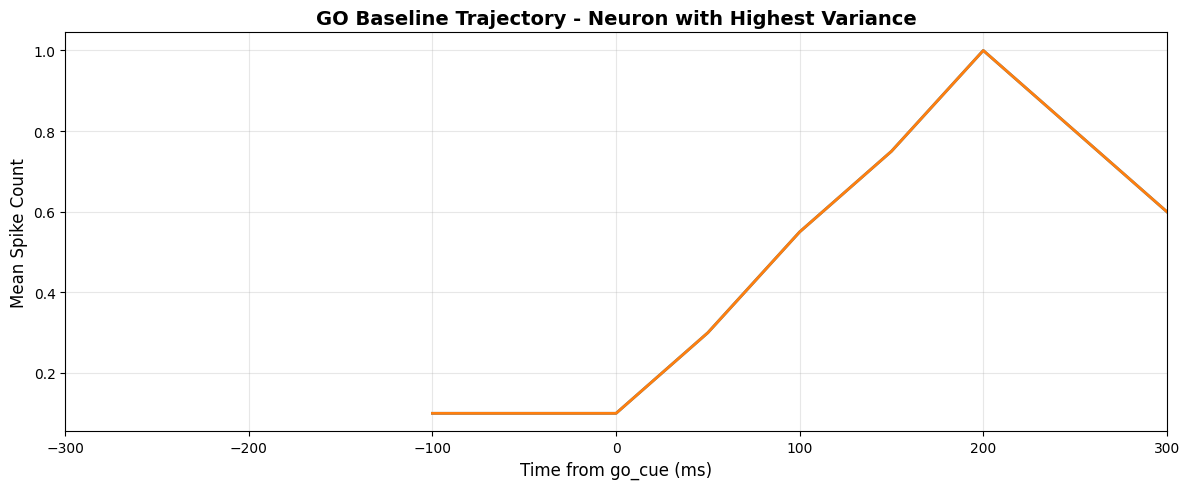

In [29]:
go_baseline.keys()
top_mu = go_baseline['mu_hat'][go_baseline['mu_hat'].var(axis=1).argmax()]
plt.figure(figsize=(12, 5))
# plt.plot(go_filtered['bin_centers'], top_mu, linewidth=2)
# plt.plot(go_filtered['bin_centers'], go_baseline['mu_hat'].T, linewidth=2)
plt.plot(go_filtered['bin_centers'], tmp_mu[:3].T, linewidth=2)
plt.xlabel('Time from go_cue (ms)', fontsize=12)
plt.ylabel('Mean Spike Count', fontsize=12)
plt.title('GO Baseline Trajectory - Neuron with Highest Variance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(epok[0], epok[1])
plt.tight_layout()
plt.show()

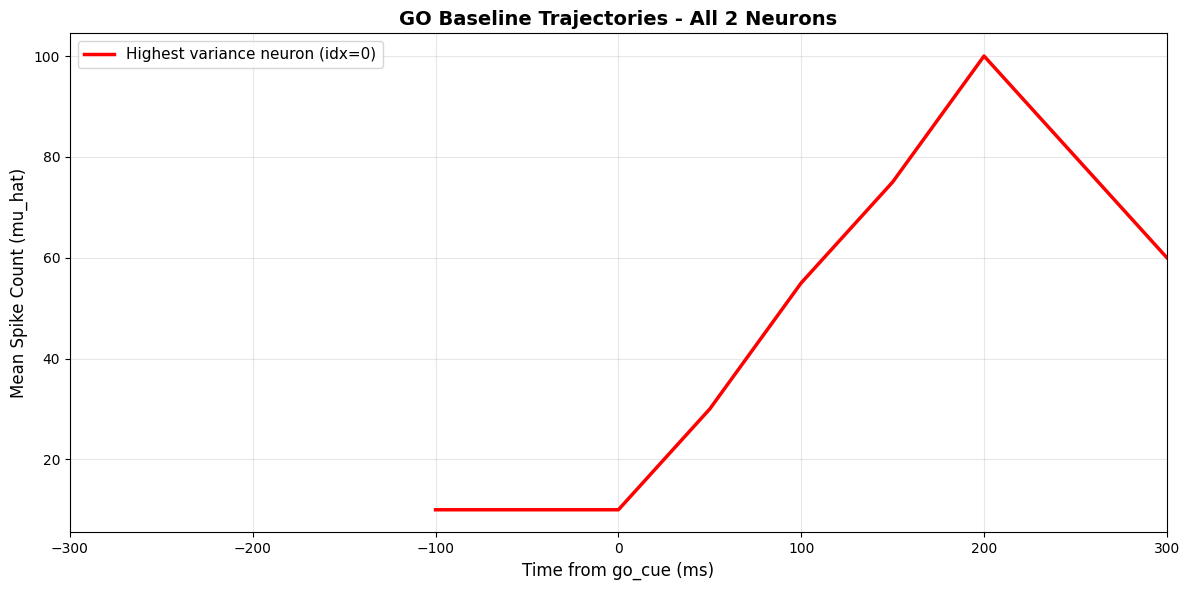

In [30]:
plt.figure(figsize=(12, 6))

# Plot all neurons' mu_hat trajectories
for neuron_idx in range(go_baseline['mu_hat'].shape[0]):
    plt.plot(go_filtered['bin_centers'], go_baseline['mu_hat'][neuron_idx, :], 
             alpha=0.3, linewidth=0.8, color='steelblue')

# Highlight the neuron with highest variance
top_neuron_idx = go_baseline['mu_hat'].var(axis=1).argmax()
plt.plot(go_filtered['bin_centers'], go_baseline['mu_hat'][top_neuron_idx, :], 
         linewidth=2.5, color='red', label=f'Highest variance neuron (idx={top_neuron_idx})')

plt.xlabel('Time from go_cue (ms)', fontsize=12)
plt.ylabel('Mean Spike Count (mu_hat)', fontsize=12)
plt.title(f'GO Baseline Trajectories - All {go_baseline["mu_hat"].shape[0]} Neurons', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(epok[0], epok[1])
plt.tight_layout()
plt.show()

## 8. Surprise Calculation

Compute per-bin negative log-likelihood (surprise) and cumulative surprise for trials.

In [31]:
def compute_surprise(trial_counts, mu_hat, smooth=False, smooth_ker_size=5):
    """
    Compute per-bin surprise and cumulative surprise for trials.
    
    Parameters:
    -----------
    trial_counts : np.ndarray
        Shape (n_trials, n_neurons, n_bins) or (n_neurons, n_bins) for single trial
    mu_hat : np.ndarray
        Shape (n_neurons, n_bins) - Poisson mean from GO baseline
    smooth : bool
        If True, apply Gaussian smoothing to s_t before computing S_t
    smooth_ker_size : int
        Kernel size (sigma) for Gaussian smoothing (default: 10)
    
    Returns:
    --------
    dict : {
        's_t': per-bin surprise (n_trials, n_bins),
        'S_t': cumulative surprise (n_trials, n_bins)
    }
    """
    # Handle single trial case
    if trial_counts.ndim == 2:
        trial_counts = trial_counts[np.newaxis, :, :]  # Add trial dimension
    
    n_trials, n_neurons, n_bins = trial_counts.shape
    
    # Compute Poisson log-likelihood for each observation
    # log P(y|mu) = y*log(mu) - mu - log(y!)
    # Use gammaln for stable log factorial: log(y!) = gammaln(y+1)
    
    y = trial_counts  # (n_trials, n_neurons, n_bins)
    mu = mu_hat[np.newaxis, :, :]  # Broadcast to (1, n_neurons, n_bins)
    
    # Compute log likelihood
    log_lik = y * np.log(mu) - mu - gammaln(y + 1)
    
    # Per-bin surprise: negative log-likelihood summed over neurons
    s_t = -log_lik.sum(axis=1)  # (n_trials, n_bins)
    
    # Apply Gaussian smoothing to s_t if requested
    if smooth:
        from scipy.ndimage import gaussian_filter1d
        # Smooth each trial independently along time axis
        s_t_smoothed = np.zeros_like(s_t)
        for trial_idx in range(n_trials):
            s_t_smoothed[trial_idx, :] = gaussian_filter1d(s_t[trial_idx, :], sigma=smooth_ker_size)
        s_t = s_t_smoothed
    
    # Cumulative surprise (computed from smoothed s_t if smoothing was applied)
    S_t = np.cumsum(s_t, axis=1)  # (n_trials, n_bins)
    
    return {
        's_t': s_t,
        'S_t': S_t
    }

print("Surprise calculation function defined!")

Surprise calculation function defined!


## 9. Calibration Threshold

Calibrate family-wise threshold from held-out GO trials.

In [32]:
def calibrate_threshold(calib_counts, mu_hat, alpha=0.05, delta=1e-9):
    """
    Calibrate family-wise divergence threshold from held-out GO trials.
    
    Parameters:
    -----------
    calib_counts : np.ndarray
        Shape (n_calib_trials, n_neurons, n_bins) - calibration GO trials
    mu_hat : np.ndarray
        Shape (n_neurons, n_bins) - fitted GO baseline
    alpha : float
        Family-wise false alarm rate (default: 0.001)
    delta : float
        Small value for numerical stability in z-score (default: 1e-9)
    
    Returns:
    --------
    dict : {
        'm_t': mean cumulative surprise over time (n_bins,),
        'sigma_t': std of cumulative surprise over time (n_bins,),
        'z_thr': threshold for divergence detection (scalar),
        'z_max_calib': max z-score per calibration trial (n_calib_trials,),
        'S_calib': cumulative surprise for calibration trials (n_calib_trials, n_bins)
    }
    """
    # Compute surprise for calibration trials
    surprise_calib = compute_surprise(calib_counts, mu_hat)
    S_calib = surprise_calib['S_t']  # (n_calib_trials, n_bins)
    
    # Compute mean and std across calibration trials
    m_t = S_calib.mean(axis=0)  # (n_bins,)
    sigma_t = S_calib.std(axis=0)  # (n_bins,)
    
    # Standardize each trial's cumulative surprise
    z_calib = (S_calib - m_t[np.newaxis, :]) / (sigma_t[np.newaxis, :] + delta)  # (n_calib_trials, n_bins)
    
    # Compute max z-score over time for each calibration trial
    z_max_calib = z_calib.max(axis=1)  # (n_calib_trials,)
    
    # Set threshold at (1-alpha) quantile of max z-scores
    z_thr = np.quantile(z_max_calib, 1 - alpha)
    
    print(f"\nCalibration threshold estimation:")
    print(f"  - Calibration trials: {calib_counts.shape[0]}")
    print(f"  - Alpha (false alarm rate): {alpha}")
    print(f"  - z_thr: {z_thr:.3f}")
    print(f"  - z_max range: {z_max_calib.min():.3f} - {z_max_calib.max():.3f}")
    print(f"  - m_t range: {m_t.min():.1f} - {m_t.max():.1f}")
    print(f"  - sigma_t range: {sigma_t.min():.1f} - {sigma_t.max():.1f}")
    
    return {
        'm_t': m_t,
        'sigma_t': sigma_t,
        'z_thr': z_thr,
        'z_max_calib': z_max_calib,
        'S_calib': S_calib,
        'z_calib': z_calib
    }

print("Calibration threshold function defined!")

Calibration threshold function defined!


## 10. Divergence Time Detection

Detect when STOP trials diverge from GO baseline.

In [33]:
def detect_divergence_times(trial_counts, mu_hat, calibration, bin_centers, delta=1e-9):
    """
    Detect divergence times for STOP trials.
    
    Parameters:
    -----------
    trial_counts : np.ndarray
        Shape (n_trials, n_neurons, n_bins) - STOP trial spike counts
    mu_hat : np.ndarray
        Shape (n_neurons, n_bins) - GO baseline
    calibration : dict
        Output from calibrate_threshold() containing m_t, sigma_t, z_thr
    bin_centers : np.ndarray
        Bin center times in ms
    delta : float
        Small value for numerical stability
    
    Returns:
    --------
    dict : {
        'tau_ms': divergence times in ms (n_trials,), None if no divergence,
        'tau_bin_idx': divergence bin indices (n_trials,), None if no divergence,
        'S_t': cumulative surprise (n_trials, n_bins),
        'z_t': standardized surprise (n_trials, n_bins),
        's_t': per-bin surprise (n_trials, n_bins)
    }
    """
    # Compute surprise for STOP trials
    surprise = compute_surprise(trial_counts, mu_hat)
    S_t = surprise['S_t']
    s_t = surprise['s_t']
    
    # Standardize using calibration statistics
    m_t = calibration['m_t']
    sigma_t = calibration['sigma_t']
    z_thr = calibration['z_thr']
    
    z_t = (S_t - m_t[np.newaxis, :]) / (sigma_t[np.newaxis, :] + delta)
    
    # Find first crossing of threshold for each trial
    n_trials = trial_counts.shape[0]
    tau_bin_idx = np.full(n_trials, None, dtype=object)
    tau_ms = np.full(n_trials, None, dtype=object)
    
    for trial_idx in range(n_trials):
        # Find first time point where z(t) > z_thr
        crossings = np.where(z_t[trial_idx, :] > z_thr)[0]
        
        if len(crossings) > 0:
            tau_bin_idx[trial_idx] = crossings[0]
            tau_ms[trial_idx] = bin_centers[crossings[0]]
    
    n_diverged = np.sum([x is not None for x in tau_ms])
    
    print(f"\nDivergence detection:")
    print(f"  - Total trials: {n_trials}")
    print(f"  - Diverged trials: {n_diverged} ({100*n_diverged/n_trials:.1f}%)")
    print(f"  - Non-diverged trials: {n_trials - n_diverged}")
    if n_diverged > 0:
        diverged_times = [t for t in tau_ms if t is not None]
        print(f"  - Divergence time range: {np.min(diverged_times):.1f} - {np.max(diverged_times):.1f} ms")
        print(f"  - Mean divergence time: {np.mean(diverged_times):.1f} ms")
    
    return {
        'tau_ms': tau_ms,
        'tau_bin_idx': tau_bin_idx,
        'S_t': S_t,
        'z_t': z_t,
        's_t': s_t
    }

print("Divergence detection function defined!")

Divergence detection function defined!


## 11. Test Full Pipeline: GO Calibration + STOP Divergence

Test the complete pipeline on GO Right and STOP SSD2 Right trials.

### Validation: GO Train vs Calibration Surprise Traces

Compare surprise trajectories between training and calibration GO trials to validate the split.


Neuron matching:
  - GO neurons: 2
  - STOP neurons: 2
  - Common neurons: 2
  - Missing in STOP: set()
  - Missing in GO: set()

Filtered shapes:
  - mu_hat_common: (2, 9)
  - stop_counts_temp: (2, 2, 9)


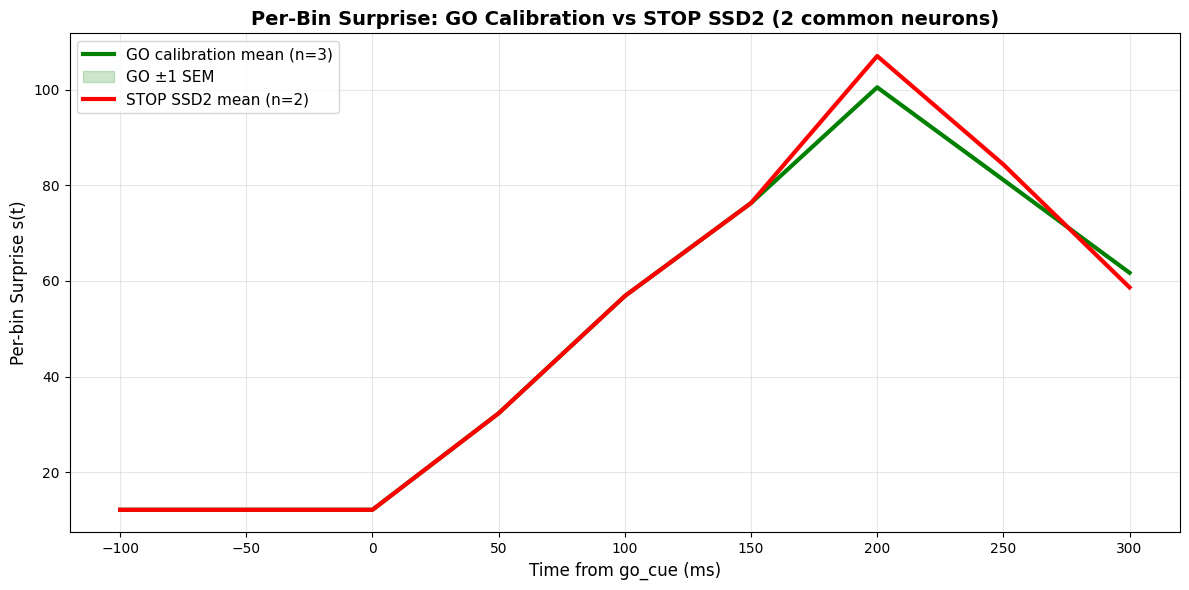


GO calibration trials: 3
STOP SSD2 trials: 2
GO mean s(t) (across time): 49.5
STOP mean s(t) (across time): 50.2


In [34]:
# Get per-bin surprise for GO calibration trials
surprise_calib = compute_surprise(go_baseline['calib_counts'], go_baseline['mu_hat'])
s_calib = surprise_calib['s_t']  # (n_calib_trials, n_bins) - per-bin surprise

# Get STOP SSD2 trials and compute their surprise
stop_binned_temp = bin_spikes_for_trials(
    session.data,
    trial_type='STOP',
    direction=direction,
    ssd_number=ssd_num,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)

# Find common neurons between GO and STOP
go_cell_ids = set(go_filtered['cell_ids'])
stop_cell_ids = set(stop_binned_temp['cell_ids'])
common_cell_ids = sorted(go_cell_ids & stop_cell_ids)  # Intersection

print(f"\nNeuron matching:")
print(f"  - GO neurons: {len(go_cell_ids)}")
print(f"  - STOP neurons: {len(stop_cell_ids)}")
print(f"  - Common neurons: {len(common_cell_ids)}")
print(f"  - Missing in STOP: {go_cell_ids - stop_cell_ids}")
print(f"  - Missing in GO: {stop_cell_ids - go_cell_ids}")

# Create index mappings for both GO and STOP
go_cell_to_idx = {cid: idx for idx, cid in enumerate(go_filtered['cell_ids'])}
stop_cell_to_idx = {cid: idx for idx, cid in enumerate(stop_binned_temp['cell_ids'])}

go_common_indices = [go_cell_to_idx[cid] for cid in common_cell_ids]
stop_common_indices = [stop_cell_to_idx[cid] for cid in common_cell_ids]

# Filter GO baseline to common neurons
mu_hat_common = go_baseline['mu_hat'][go_common_indices, :]

# Filter STOP counts to common neurons
stop_counts_temp = stop_binned_temp['counts'][:, stop_common_indices, :]

print(f"\nFiltered shapes:")
print(f"  - mu_hat_common: {mu_hat_common.shape}")
print(f"  - stop_counts_temp: {stop_counts_temp.shape}")

# Compute per-bin surprise for STOP trials
surprise_stop = compute_surprise(stop_counts_temp, mu_hat_common, smooth=False)
s_stop = surprise_stop['s_t']  # (n_stop_trials, n_bins) - per-bin surprise

# Compute GO mean and SEM
s_calib_mean = s_calib.mean(axis=0)
s_calib_sem = s_calib.std(axis=0) / np.sqrt(s_calib.shape[0])

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot GO mean with shaded SEM region
ax.plot(go_filtered['bin_centers'], s_calib_mean, 
        color='green', linewidth=3, label=f'GO calibration mean (n={s_calib.shape[0]})')
ax.fill_between(go_filtered['bin_centers'], 
                s_calib_mean - s_calib_sem, 
                s_calib_mean + s_calib_sem,
                color='green', alpha=0.2, label='GO ±1 SEM')

# Plot all STOP SSD2 trials in red
for i in range(s_stop.shape[0]):
    ax.plot(go_filtered['bin_centers'], s_stop[i, :], 
            color='red', alpha=0.3, linewidth=0.8)

# Plot mean STOP SSD2 in red (solid)
ax.plot(go_filtered['bin_centers'], s_stop.mean(axis=0), 
        color='red', linewidth=3, label=f'STOP SSD{ssd_num} mean (n={s_stop.shape[0]})')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Per-bin Surprise s(t)', fontsize=12)
ax.set_title(f'Per-Bin Surprise: GO Calibration vs STOP SSD2 ({len(common_cell_ids)} common neurons)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGO calibration trials: {s_calib.shape[0]}")
print(f"STOP SSD2 trials: {s_stop.shape[0]}")
print(f"GO mean s(t) (across time): {s_calib.mean():.1f}")
print(f"STOP mean s(t) (across time): {s_stop.mean():.1f}")

In [35]:
s_calib.shape, s_stop.shape
# surprise_calib, surprise_stop
surprise_stop['S_t'].shape

(2, 9)

In [36]:
# Run complete pipeline
print("=" * 60)
print("COMPLETE PIPELINE TEST: GO Right -> STOP SSD2 Right")
print("=" * 60)

# 1. Get STOP SSD2 trials
stop_binned = bin_spikes_for_trials(
    session.data,
    trial_type='STOP',
    direction=direction,
    ssd_number=ssd_num,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)

# 2. Find common neurons between GO and STOP
go_cell_ids = set(go_filtered['cell_ids'])
stop_cell_ids = set(stop_binned['cell_ids'])
common_cell_ids = sorted(go_cell_ids & stop_cell_ids)

print(f"\nNeuron matching:")
print(f"  - GO neurons: {len(go_cell_ids)}")
print(f"  - STOP neurons: {len(stop_cell_ids)}")
print(f"  - Common neurons: {len(common_cell_ids)}")
if go_cell_ids - stop_cell_ids:
    print(f"  - Missing in STOP: {go_cell_ids - stop_cell_ids}")
if stop_cell_ids - go_cell_ids:
    print(f"  - Missing in GO: {stop_cell_ids - go_cell_ids}")

# 3. Create index mappings for both GO and STOP
go_cell_to_idx = {cid: idx for idx, cid in enumerate(go_filtered['cell_ids'])}
stop_cell_to_idx = {cid: idx for idx, cid in enumerate(stop_binned['cell_ids'])}

go_common_indices = [go_cell_to_idx[cid] for cid in common_cell_ids]
stop_common_indices = [stop_cell_to_idx[cid] for cid in common_cell_ids]

# 4. Filter GO baseline and calibration counts to common neurons
mu_hat_common = go_baseline['mu_hat'][go_common_indices, :]
calib_counts_common = go_baseline['calib_counts'][:, go_common_indices, :]

print(f"\nFiltered GO baseline:")
print(f"  - mu_hat shape: {mu_hat_common.shape}")
print(f"  - calib_counts shape: {calib_counts_common.shape}")

# 5. Calibrate threshold using filtered GO data
calibration = calibrate_threshold(
    calib_counts_common,
    mu_hat_common,
    alpha=0.001
)

# 6. Filter STOP counts to common neurons
stop_counts_filtered = stop_binned['counts'][:, stop_common_indices, :]

print(f"\nSTOP trial filtering:")
print(f"  - STOP SSD2 trials: {stop_counts_filtered.shape[0]}")
print(f"  - Neurons (matched to GO): {stop_counts_filtered.shape[1]}")
print(f"  - Bins: {stop_counts_filtered.shape[2]}")

# 7. Detect divergence times
divergence = detect_divergence_times(
    stop_counts_filtered,
    mu_hat_common,
    calibration,
    go_filtered['bin_centers']
)

print("\n" + "=" * 60)
print("Pipeline test complete!")

COMPLETE PIPELINE TEST: GO Right -> STOP SSD2 Right

Neuron matching:
  - GO neurons: 2
  - STOP neurons: 2
  - Common neurons: 2

Filtered GO baseline:
  - mu_hat shape: (2, 9)
  - calib_counts shape: (3, 2, 9)

Calibration threshold estimation:
  - Calibration trials: 3
  - Alpha (false alarm rate): 0.001
  - z_thr: 0.000
  - z_max range: 0.000 - 0.000
  - m_t range: 12.2 - 445.3
  - sigma_t range: 0.0 - 0.0

STOP trial filtering:
  - STOP SSD2 trials: 2
  - Neurons (matched to GO): 2
  - Bins: 9

Divergence detection:
  - Total trials: 2
  - Diverged trials: 2 (100.0%)
  - Non-diverged trials: 0
  - Divergence time range: 200.0 - 200.0 ms
  - Mean divergence time: 200.0 ms

Pipeline test complete!


## 12. Visualization: Single Trial Trace

Plot S(t), z(t), and divergence time for individual STOP trials.

In [37]:
def plot_single_trial_trace(trial_idx, divergence, calibration, bin_centers, 
                            trial_numbers=None, figsize=(12, 8)):
    """
    Plot S(t), z(t), and divergence time for a single trial.
    
    Parameters:
    -----------
    trial_idx : int
        Index of trial to plot
    divergence : dict
        Output from detect_divergence_times()
    calibration : dict
        Output from calibrate_threshold()
    bin_centers : np.ndarray
        Bin center times in ms
    trial_numbers : list, optional
        Original trial numbers
    figsize : tuple
        Figure size
    """
    S_t = divergence['S_t'][trial_idx, :]
    z_t = divergence['z_t'][trial_idx, :]
    tau_ms = divergence['tau_ms'][trial_idx]
    
    m_t = calibration['m_t']
    sigma_t = calibration['sigma_t']
    z_thr = calibration['z_thr']
    
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    # Plot 1: Cumulative surprise S(t)
    ax1 = axes[0]
    ax1.plot(bin_centers, S_t, 'b-', linewidth=2, label='S(t) - STOP trial')
    ax1.plot(bin_centers, m_t, 'g--', linewidth=1.5, label='m(t) - GO mean', alpha=0.7)
    ax1.fill_between(bin_centers, m_t - sigma_t, m_t + sigma_t, 
                      color='green', alpha=0.2, label='±1 σ(t)')
    
    if tau_ms is not None:
        ax1.axvline(tau_ms, color='red', linestyle='--', linewidth=2, 
                   label=f'Divergence: {tau_ms:.1f} ms')
    
    ax1.set_ylabel('Cumulative Surprise S(t)', fontsize=12)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'Trial {trial_numbers[trial_idx] if trial_numbers else trial_idx}: ' +
                  f'Trajectory Divergence Analysis', fontsize=14, fontweight='bold')
    
    # Plot 2: Standardized surprise z(t)
    ax2 = axes[1]
    ax2.plot(bin_centers, z_t, 'b-', linewidth=2, label='z(t) - STOP trial')
    ax2.axhline(0, color='g', linestyle='--', linewidth=1.5, label='GO baseline (z=0)', alpha=0.7)
    ax2.axhline(z_thr, color='orange', linestyle='--', linewidth=2, 
               label=f'Threshold: {z_thr:.2f}', alpha=0.8)
    
    if tau_ms is not None:
        ax2.axvline(tau_ms, color='red', linestyle='--', linewidth=2, 
                   label=f'Divergence: {tau_ms:.1f} ms')
    
    ax2.set_xlabel('Time from go_cue (ms)', fontsize=12)
    ax2.set_ylabel('Standardized Surprise z(t)', fontsize=12)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

print("Single trial plotting function defined!")

Single trial plotting function defined!


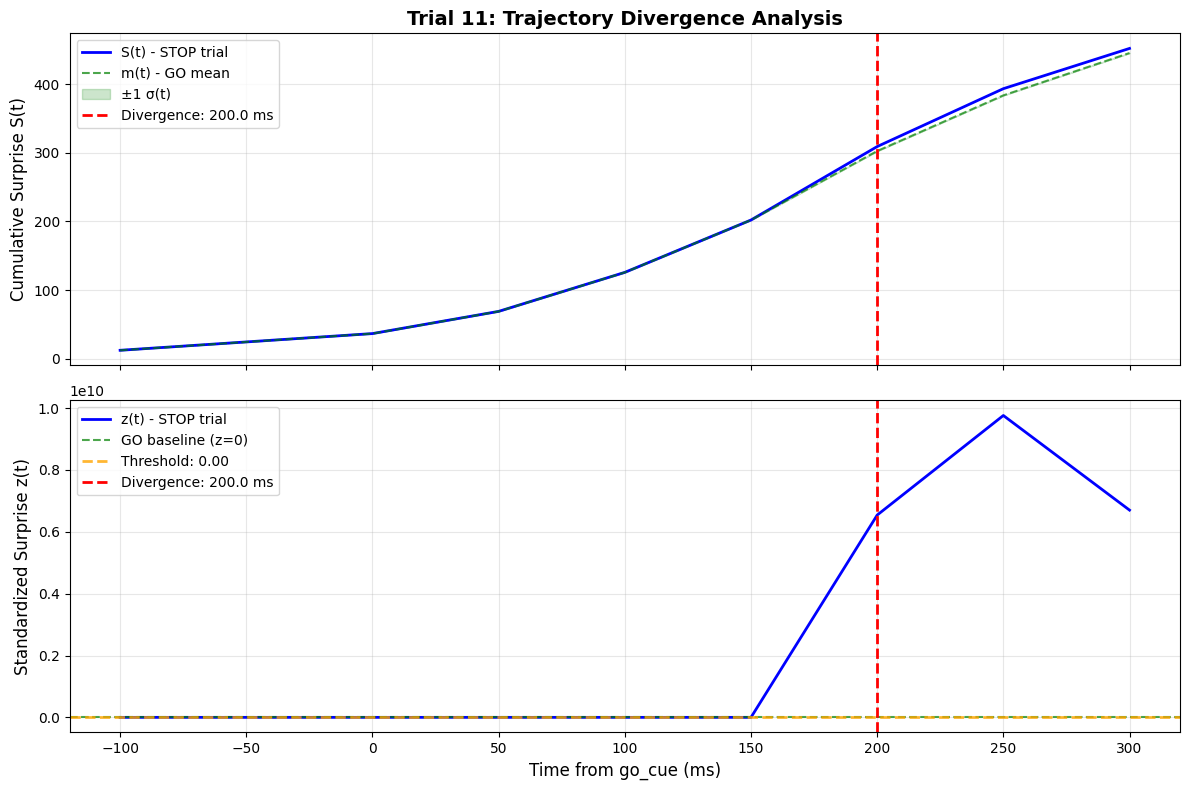

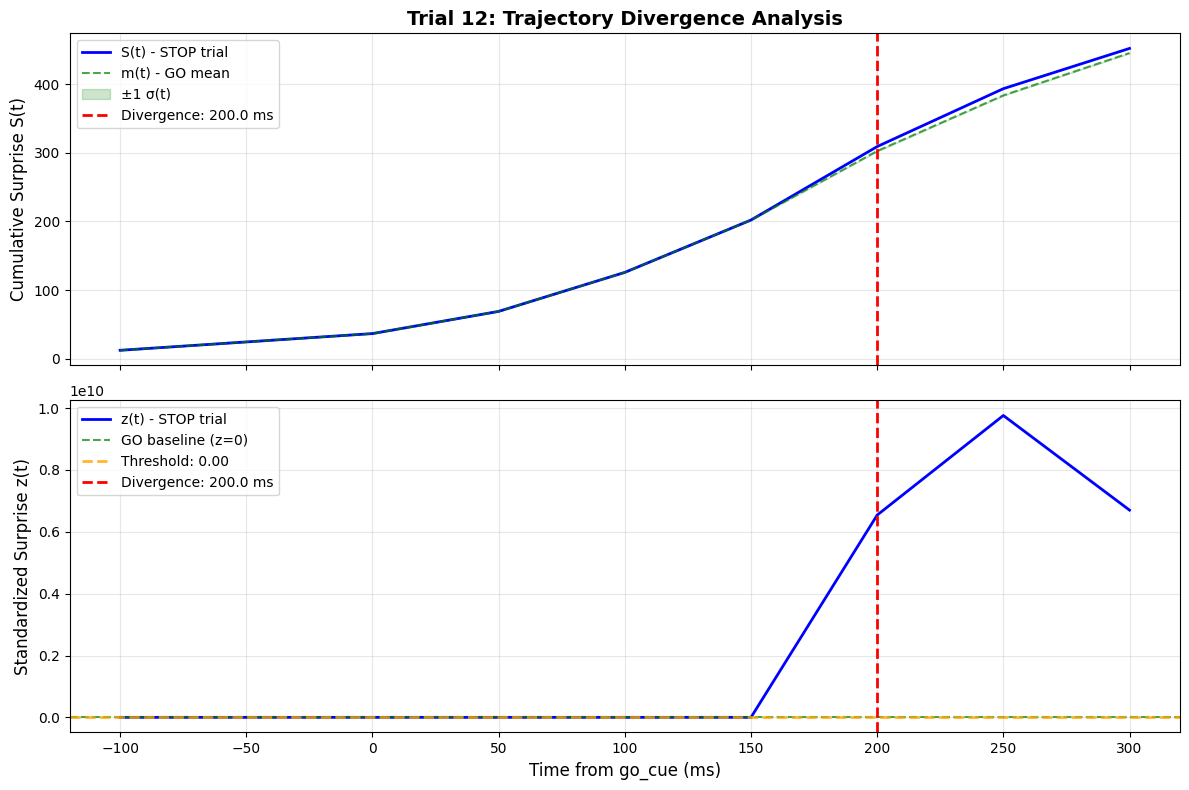

In [38]:
# Plot first 3 STOP trials as examples
for i in range(min(3, len(divergence['tau_ms']))):
    fig = plot_single_trial_trace(
        trial_idx=i,
        divergence=divergence,
        calibration=calibration,
        bin_centers=go_filtered['bin_centers'],
        trial_numbers=stop_binned['trial_numbers']
    )
    plt.show()

## 13. Divergence Time Distribution

Visualize the distribution of divergence times across all STOP SSD2 trials.

In [39]:
def plot_divergence_distribution(divergence, direction_label='', figsize=(12, 5)):
    """
    Plot distribution of divergence times.
    
    Parameters:
    -----------
    divergence : dict
        Output from detect_divergence_times()
    direction_label : str
        Label for direction (e.g., 'Right', 'Left')
    figsize : tuple
        Figure size
    """
    tau_ms = divergence['tau_ms']
    
    # Extract diverged trials only
    diverged_times = [t for t in tau_ms if t is not None]
    n_total = len(tau_ms)
    n_diverged = len(diverged_times)
    n_no_diverge = n_total - n_diverged
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Histogram of divergence times
    ax1 = axes[0]
    if n_diverged > 0:
        ax1.hist(diverged_times, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
        ax1.axvline(np.mean(diverged_times), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(diverged_times):.1f} ms')
        ax1.axvline(np.median(diverged_times), color='orange', linestyle='--', 
                   linewidth=2, label=f'Median: {np.median(diverged_times):.1f} ms')
    
    ax1.set_xlabel('Divergence Time (ms from go_cue)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title(f'Divergence Time Distribution\n{direction_label} Direction', 
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Summary bar chart
    ax2 = axes[1]
    categories = ['Diverged', 'No Divergence']
    counts = [n_diverged, n_no_diverge]
    colors = ['steelblue', 'lightcoral']
    
    bars = ax2.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_ylabel('Number of Trials', fontsize=12)
    ax2.set_title(f'Divergence Detection Summary\n{direction_label} Direction', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{count} ({100*count/n_total:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    return fig

print("Divergence distribution plotting function defined!")

Divergence distribution plotting function defined!


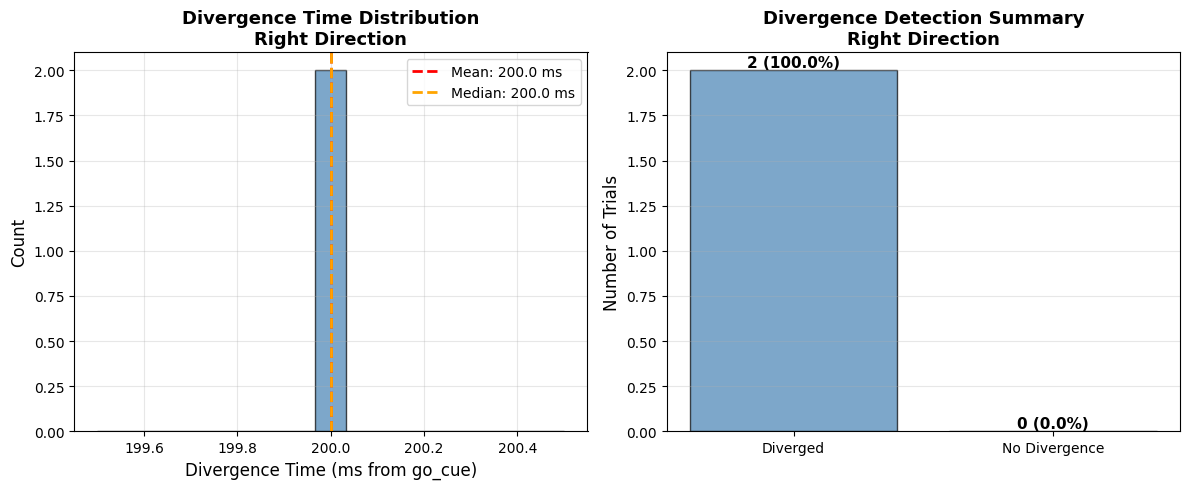

In [40]:
# Plot divergence time distribution
fig = plot_divergence_distribution(divergence, direction_label='Right')
plt.show()